# Klasifikasi Sampah Organik & Non-Organik Berbasis Algoritma K-Nearest Neighbor (KNN)

Notebook ini berisi alur eksperimen lengkap untuk pengembangan model klasifikasi sampah rumah tangga:
- **Preprocessing Citra**: Penyesuaian ukuran (*resize*) ke dimensi standar 128x128 piksel dan normalisasi.
- **Ekstraksi Fitur**: 
  - Color Histogram (HSV)
  - Local Binary Patterns (LBP)
  - Histogram of Oriented Gradients (HOG)
  - Combined (Color Histogram + LBP)
- **Pelatihan KNN & Grid Search K**: Mencari nilai $K$ terbaik ($K \in [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]$).
- **Evaluasi Model**: Akurasi, Presisi, Recall, F1-Score, dan Visualisasi Confusion Matrix.
- **Simulasi Inference NumPy**: Pembuktian pencarian tetangga terdekat secara matematis menggunakan NumPy.

In [1]:
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern, hog
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 1. Spesifikasi Dataset
Kita memindai direktori dataset untuk menghitung jumlah citra latih (TRAIN) dan uji (TEST) pada setiap kelas.

In [2]:
train_dir = r"DATASET/TRAIN"
test_dir = r"DATASET/TEST"

def count_files(dir_path):
    classes = ['organik', 'non-organik']
    counts = {}
    for cls in classes:
        cls_path = os.path.join(dir_path, cls)
        if os.path.exists(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
        else:
            counts[cls] = 0
    return counts

train_counts = count_files(train_dir)
test_counts = count_files(test_dir)

print("Jumlah Dataset Latih (TRAIN):")
print(f"  Organik: {train_counts['organik']} citra")
print(f"  Non-Organik: {train_counts['non-organik']} citra")
print(f"  Total: {sum(train_counts.values())} citra")

print("\nJumlah Dataset Uji (TEST):")
print(f"  Organik: {test_counts['organik']} citra")
print(f"  Non-Organik: {test_counts['non-organik']} citra")
print(f"  Total: {sum(test_counts.values())} citra")

Jumlah Dataset Latih (TRAIN):
  Organik: 12565 citra
  Non-Organik: 9999 citra
  Total: 22564 citra

Jumlah Dataset Uji (TEST):
  Organik: 1401 citra
  Non-Organik: 1112 citra
  Total: 2513 citra


## 2. Implementasi Ekstraksi Fitur
Di bawah ini didefinisikan fungsi ekstraksi fitur Color Histogram, LBP, HOG, dan penggabungan (Combined) dari citra.

In [3]:
def extract_color_histogram(img):
    img_resized = cv2.resize(img, (128, 128))
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [8], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [8], [0, 256])
    hist_v = cv2.calcHist([hsv], [2], None, [8], [0, 256])
    hist_color = np.concatenate([hist_h, hist_s, hist_v]).flatten()
    sum_val = hist_color.sum()
    if sum_val > 0:
        hist_color /= sum_val
    return hist_color

def extract_lbp(img):
    img_resized = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    n_bins = int(lbp.max() + 1)
    hist_lbp, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist_lbp = hist_lbp.astype("float32")
    sum_lbp = hist_lbp.sum()
    if sum_lbp > 0:
        hist_lbp /= sum_lbp
    return hist_lbp

def extract_hog(img):
    img_resized = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=False)
    return hog_feat

def extract_combined(img):
    color = extract_color_histogram(img)
    lbp = extract_lbp(img)
    return np.concatenate([color, lbp])

## 3. Visualisasi Sampel Citra & Representasi Fitur
Menampilkan citra asli beserta visualisasi representasi fitur warna, tekstur (LBP), dan bentuk (HOG) untuk membandingkan karakteristik sampah.

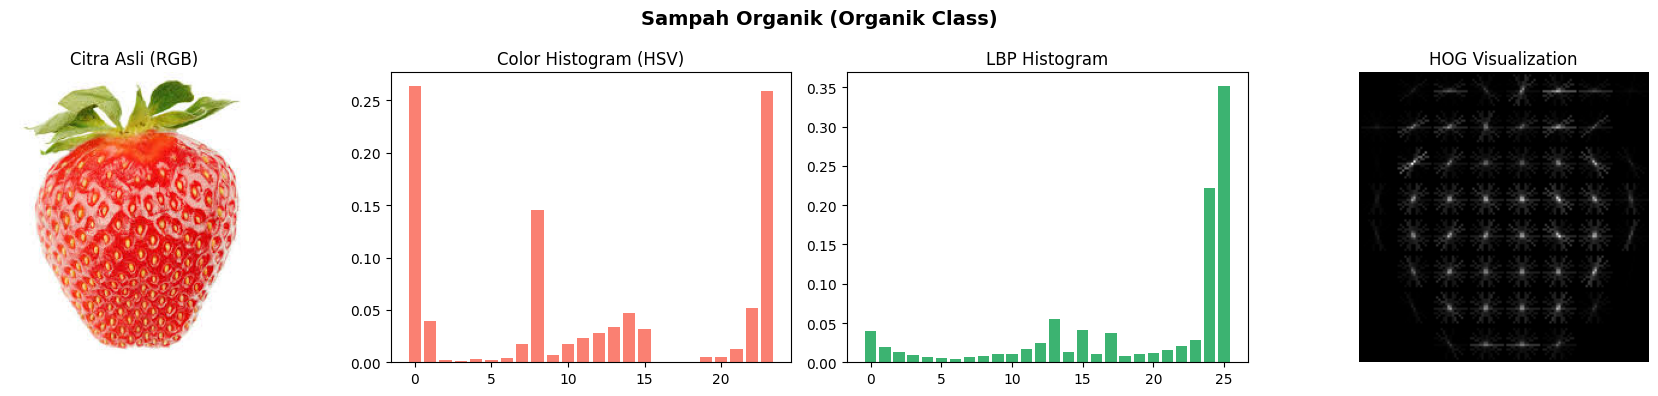

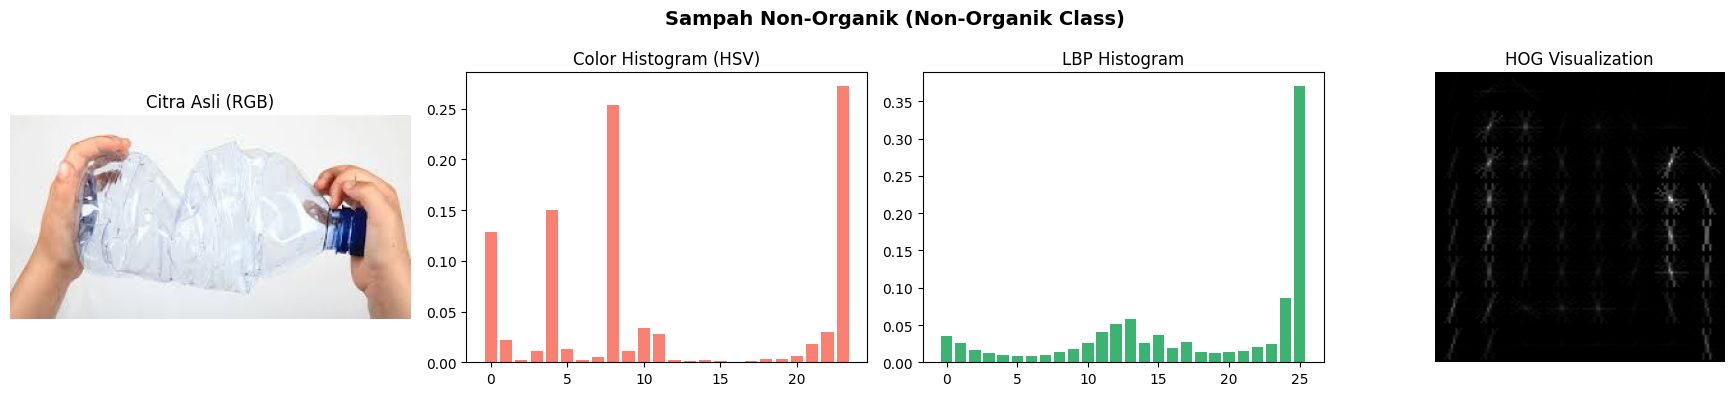

In [4]:
def visualize_sample(img_path, title):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Gagal memuat {img_path}")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    color_hist = extract_color_histogram(img)
    lbp_hist = extract_lbp(img)
    
    img_resized = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    hog_feat, hog_img = hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True)
    
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    axs[0].imshow(img_rgb)
    axs[0].set_title("Citra Asli (RGB)")
    axs[0].axis('off')
    
    axs[1].bar(range(len(color_hist)), color_hist, color='salmon')
    axs[1].set_title("Color Histogram (HSV)")
    
    axs[2].bar(range(len(lbp_hist)), lbp_hist, color='mediumseagreen')
    axs[2].set_title("LBP Histogram")
    
    axs[3].imshow(hog_img, cmap='gray')
    axs[3].set_title("HOG Visualization")
    axs[3].axis('off')
    
    plt.tight_layout()
    plt.show()

org_samples = [os.path.join(train_dir, 'organik', f) for f in os.listdir(os.path.join(train_dir, 'organik')) if f.lower().endswith(('.jpg', '.png'))]
non_samples = [os.path.join(train_dir, 'non-organik', f) for f in os.listdir(os.path.join(train_dir, 'non-organik')) if f.lower().endswith(('.jpg', '.png'))]

if org_samples:
    visualize_sample(org_samples[0], "Sampah Organik (Organik Class)")
if non_samples:
    visualize_sample(non_samples[0], "Sampah Non-Organik (Non-Organik Class)")

## 4. Pemrosesan Data & Ekstraksi Fitur Dataset
Kita memuat citra latih dan uji, lalu mengekstraksi fiturnya. Untuk mempercepat eksekusi notebook secara interaktif, kita dapat membatasi ukuran sampel (*sampling*).

In [5]:
LIMIT_SAMPLES = True
LIMIT_TRAIN = 1500
LIMIT_TEST = 300

def load_and_extract(dir_path, limit=None):
    classes = ['organik', 'non-organik']
    features = {
        "color": [], "lbp": [], "hog": [], "combined": [],
        "labels": [], "filenames": [], "paths": []
    }
    
    for cls in classes:
        cls_dir = os.path.join(dir_path, cls)
        if not os.path.exists(cls_dir):
            continue
        label = "Organik" if cls == "organik" else "Non-Organik"
        
        filenames = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        if limit:
            filenames = filenames[:limit // 2]
            
        for fname in filenames:
            full_path = os.path.join(cls_dir, fname)
            img = cv2.imread(full_path)
            if img is None:
                continue
            
            features["color"].append(extract_color_histogram(img))
            features["lbp"].append(extract_lbp(img))
            features["hog"].append(extract_hog(img))
            # combined: color + lbp
            features["combined"].append(np.concatenate([features["color"][-1], features["lbp"][-1]]))
            features["labels"].append(label)
            features["filenames"].append(fname)
            features["paths"].append(full_path)
            
    for key in ["color", "lbp", "hog", "combined"]:
        features[key] = np.array(features[key])
    features["labels"] = np.array(features["labels"])
    return features

print("Mengekstrak fitur dataset...")
t_start = time.time()
train_data = load_and_extract(train_dir, limit=LIMIT_TRAIN if LIMIT_SAMPLES else None)
test_data = load_and_extract(test_dir, limit=LIMIT_TEST if LIMIT_SAMPLES else None)
print(f"Selesai dalam {time.time() - t_start:.2f} detik.")
print(f"Data latih diekstrak: {len(train_data['labels'])} citra")
print(f"Data uji diekstrak: {len(test_data['labels'])} citra")

Mengekstrak fitur dataset...
Selesai dalam 22.16 detik.
Data latih diekstrak: 1500 citra
Data uji diekstrak: 300 citra


## 5. Grid Search Nilai K & Evaluasi Fitur
Kita menguji variasi $K \in [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]$ untuk setiap jenis fitur guna menemukan performa akurasi terbaik.

In [6]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
feature_keys = ["color", "lbp", "hog", "combined"]
feature_names = {
    "color": "Color Histogram",
    "lbp": "Local Binary Patterns (LBP)",
    "hog": "Histogram of Oriented Gradients (HOG)",
    "combined": "Histogram + LBP (Combined)"
}

results = {key: [] for key in feature_keys}

best_acc = 0.0
best_ft = None
best_k = None

for ft in feature_keys:
    print(f"Eksperimen fitur: {feature_names[ft]}")
    for k in k_values:
        clf = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        clf.fit(train_data[ft], train_data["labels"])
        preds = clf.predict(test_data[ft])
        acc = accuracy_score(test_data["labels"], preds)
        results[ft].append(acc)
        print(f"  K={k} -> Akurasi: {acc:.4f}")
        
        if acc > best_acc:
            best_acc = acc
            best_ft = ft
            best_k = k

print(f"\n=== MODEL TERBAIK ===")
print(f"Fitur Terbaik: {feature_names[best_ft]}")
print(f"Nilai K Optimal: {best_k}")
print(f"Akurasi Tertinggi: {best_acc:.4f}")

Eksperimen fitur: Color Histogram
  K=1 -> Akurasi: 0.7367
  K=3 -> Akurasi: 0.7367
  K=5 -> Akurasi: 0.7633
  K=7 -> Akurasi: 0.7667
  K=9 -> Akurasi: 0.7600
  K=11 -> Akurasi: 0.7667
  K=13 -> Akurasi: 0.7700
  K=15 -> Akurasi: 0.7667
  K=17 -> Akurasi: 0.7633
  K=19 -> Akurasi: 0.7733
Eksperimen fitur: Local Binary Patterns (LBP)
  K=1 -> Akurasi: 0.6700
  K=3 -> Akurasi: 0.6600
  K=5 -> Akurasi: 0.7067
  K=7 -> Akurasi: 0.6467
  K=9 -> Akurasi: 0.6567
  K=11 -> Akurasi: 0.6833
  K=13 -> Akurasi: 0.6700
  K=15 -> Akurasi: 0.6667
  K=17 -> Akurasi: 0.6467
  K=19 -> Akurasi: 0.6667
Eksperimen fitur: Histogram of Oriented Gradients (HOG)
  K=1 -> Akurasi: 0.5600
  K=3 -> Akurasi: 0.6867
  K=5 -> Akurasi: 0.6667
  K=7 -> Akurasi: 0.6867
  K=9 -> Akurasi: 0.6867
  K=11 -> Akurasi: 0.6833
  K=13 -> Akurasi: 0.6933
  K=15 -> Akurasi: 0.6933
  K=17 -> Akurasi: 0.6833
  K=19 -> Akurasi: 0.6967
Eksperimen fitur: Histogram + LBP (Combined)
  K=1 -> Akurasi: 0.7367
  K=3 -> Akurasi: 0.7533
  K=

## 6. Plotting Kurva Akurasi vs K
Membuat grafik garis (*line chart*) untuk menganalisis pengaruh nilai K dan metode ekstraksi fitur terhadap akurasi model.

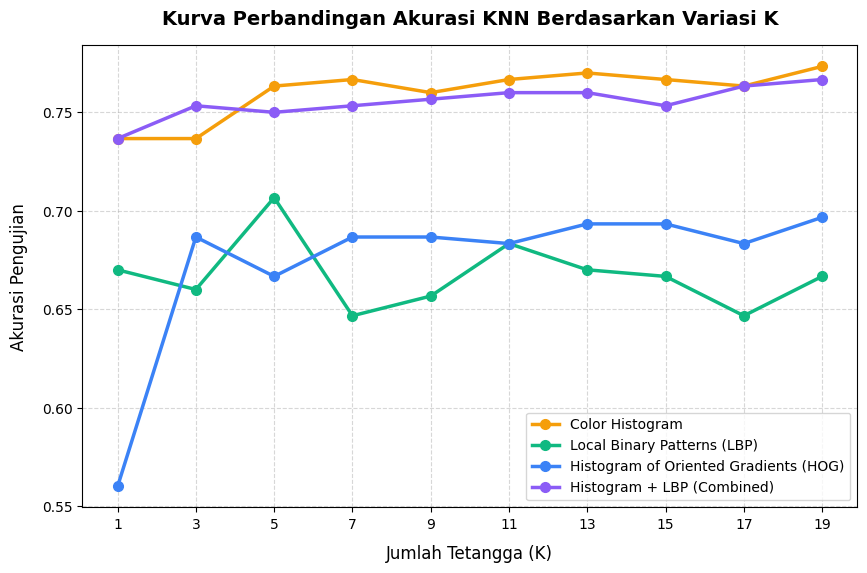

In [7]:
plt.figure(figsize=(10, 6))
colors = ['#f59e0b', '#10b981', '#3b82f6', '#8b5cf6']
for idx, ft in enumerate(feature_keys):
    plt.plot(k_values, results[ft], marker='o', label=feature_names[ft], color=colors[idx], linewidth=2.5, markersize=7)

plt.title("Kurva Perbandingan Akurasi KNN Berdasarkan Variasi K", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Jumlah Tetangga (K)", fontsize=12, labelpad=10)
plt.ylabel("Akurasi Pengujian", fontsize=12, labelpad=10)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='lower right')
plt.show()

## 7. Analisis Performa Model Terbaik
Menampilkan laporan klasifikasi (*Classification Report*) yang detail (Precision, Recall, F1-Score) dan Confusion Matrix 2x2 dari model terbaik.

Classification Report Model Terbaik:
              precision    recall  f1-score   support

 Non-Organik       0.89      0.63      0.73       150
     Organik       0.71      0.92      0.80       150

    accuracy                           0.77       300
   macro avg       0.80      0.77      0.77       300
weighted avg       0.80      0.77      0.77       300



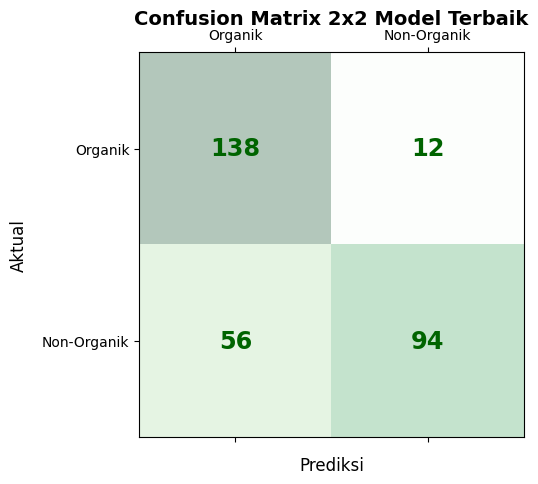

Hasil Perhitungan:
  True Positive (Organik -> Organik): 138
  True Negative (Non-Organik -> Non-Organik): 94
  False Positive (Non-Organik -> Organik): 56
  False Negative (Organik -> Non-Organik): 12


In [8]:
best_clf = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
best_clf.fit(train_data[best_ft], train_data["labels"])
y_pred = best_clf.predict(test_data[best_ft])

print("Classification Report Model Terbaik:")
print(classification_report(test_data["labels"], y_pred))

cm = confusion_matrix(test_data["labels"], y_pred, labels=["Organik", "Non-Organik"])
tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

# Visualisasi Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ax.matshow(cm, cmap=plt.cm.Greens, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='xx-large', weight='bold', color='darkgreen')

plt.xlabel('Prediksi', fontsize=12, labelpad=10)
plt.ylabel('Aktual', fontsize=12, labelpad=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Organik", "Non-Organik"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Organik", "Non-Organik"])
plt.title('Confusion Matrix 2x2 Model Terbaik', fontsize=14, fontweight='bold', pad=20)
plt.show()

print(f"Hasil Perhitungan:")
print(f"  True Positive (Organik -> Organik): {tp}")
print(f"  True Negative (Non-Organik -> Non-Organik): {tn}")
print(f"  False Positive (Non-Organik -> Organik): {fp}")
print(f"  False Negative (Organik -> Non-Organik): {fn}")

## 8. Simulasi Algoritma KNN dengan Pure NumPy (Optimasi Inferensi)
Dalam deployment web (FastAPI), kita menggunakan perhitungan NumPy murni untuk mengukur jarak Euclidean masukan uji terhadap seluruh data latih secara instan.

In [9]:
# Ambil citra pertama dari data uji
test_idx = 0
sample_path = test_data["paths"][test_idx]
actual_label = test_data["labels"][test_idx]
input_feat = test_data[best_ft][test_idx]

print(f"Citra Masukan Uji: {sample_path} (Aktual: {actual_label})\n")

# 1. Hitung jarak Euclidean menggunakan NumPy murni
train_matrix = train_data[best_ft]
diff = train_matrix - input_feat
distances = np.linalg.norm(diff, axis=1)

# 2. Cari indeks K-tetangga terdekat
nearest_idx = np.argsort(distances)[:best_k]
neighbor_labels = train_data["labels"][nearest_idx]

# 3. Voting Suara
organik_votes = np.sum(neighbor_labels == "Organik")
non_organik_votes = np.sum(neighbor_labels == "Non-Organik")

if organik_votes >= non_organik_votes:
    pred_label = "Organik"
    confidence = organik_votes / best_k
else:
    pred_label = "Non-Organik"
    confidence = non_organik_votes / best_k

print(f"--- Hasil Prediksi NumPy-Optimized (K={best_k}) ---")
print(f"Prediksi Model: {pred_label}")
print(f"Confidence Rate: {confidence:.2%}")

print(f"\nDetail Tetangga Terdekat:")
for rank, idx in enumerate(nearest_idx):
    print(f"  Rank {rank+1}: {train_data['filenames'][idx]} ({train_data['labels'][idx]}) - Distance: {distances[idx]:.4f}")

Citra Masukan Uji: DATASET/TEST\organik\O_12568.jpg (Aktual: Organik)

--- Hasil Prediksi NumPy-Optimized (K=19) ---
Prediksi Model: Organik
Confidence Rate: 100.00%

Detail Tetangga Terdekat:
  Rank 1: O_1013.jpg (Organik) - Distance: 0.0954
  Rank 2: O_102.jpg (Organik) - Distance: 0.1059
  Rank 3: O_10168.jpg (Organik) - Distance: 0.1162
  Rank 4: O_10590.jpg (Organik) - Distance: 0.1165
  Rank 5: O_1041.jpg (Organik) - Distance: 0.1174
  Rank 6: O_10617.jpg (Organik) - Distance: 0.1210
  Rank 7: O_10203.jpg (Organik) - Distance: 0.1236
  Rank 8: O_10194.jpg (Organik) - Distance: 0.1275
  Rank 9: O_10349.jpg (Organik) - Distance: 0.1294
  Rank 10: O_1020.jpg (Organik) - Distance: 0.1314
  Rank 11: O_10162.jpg (Organik) - Distance: 0.1320
  Rank 12: O_10522.jpg (Organik) - Distance: 0.1327
  Rank 13: O_1045.jpg (Organik) - Distance: 0.1332
  Rank 14: O_1006.jpg (Organik) - Distance: 0.1344
  Rank 15: O_10184.jpg (Organik) - Distance: 0.1352
  Rank 16: O_10027.jpg (Organik) - Distance